# 01 · Explore the order book, and check one parent order by hand

Phase 1 and the Phase 2 "done when" check from `QUICKSTART.md`. It reads the processed
events and 1-second grid written by `scripts/build_dataset.py` (run that first). Set the
`ADAPTIVE_EXEC_CONFIG` environment variable to use another config.

**Discipline:** the signal plot (section 3) uses the **training window only**, so nothing
here is learned from the validation or test windows. The descriptive plots show the whole
day; every modeling choice is fixed in the config before any of this is looked at.

In [1]:
import os
from pathlib import Path

ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
os.chdir(ROOT)

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Markdown, display

from adaptive_exec.pipeline import load_config
from adaptive_exec.plotting import (AXIS, INK_2, SERIES, SURFACE, DIVERGING, apply_style,
                                    ci_dots, small_multiples, zero_line)

CONFIG = os.environ.get("ADAPTIVE_EXEC_CONFIG", "configs/stage1_itch.yaml")
cfg = load_config(CONFIG)
apply_style()
pd.set_option("display.width", 160, "display.max_columns", 30)
print(f"config: {CONFIG} | stage: {cfg['stage']} | symbols: {', '.join(cfg['symbols'])}")

config: configs/stage1_itch.yaml | stage: stage1_itch | symbols: AAPL, AMZN, GOOG, INTC, MSFT


## Sanity checks from the loader

One row per stock and day, from `meta.json`. Visible executions should all sit at the best price of the previous book row, timestamps should never go backwards, and invalid (locked, crossed or one-sided) books should be rare.

In [2]:
from adaptive_exec.pipeline import available_days, load_meta

rows = []
for s in cfg["symbols"]:
    for d in available_days(cfg, s):
        m = load_meta(cfg, s, d)
        rows.append({"symbol": s, "date": d, **m["sanity"], "total_volume": m["total_volume"]})
sanity = pd.DataFrame(rows)
sanity

,symbol,date,n_events,first_second,last_second,time_monotonic,mid_min,mid_max,share_invalid_book,n_trades,share_visible_exec_at_prior_best,share_trade_volume_unknown_aggressor,fill_removals_per_trade,total_volume
0,AAPL,2019-03-27,1609680,34200.010884,57599.998278,True,186.545,189.755,0.0,61390,0.990835,0.057928,0.0,6072325.0
1,AMZN,2019-03-27,550859,34200.000585,57599.990437,True,1745.785,1787.550,0.0,33645,1.000000,0.003245,0.0,894210.0
2,GOOG,2019-03-27,807431,34200.000243,57599.998227,True,1159.235,1186.920,0.0,13472,1.000000,0.012167,0.0,412029.0
3,INTC,2019-03-27,1408546,34200.004174,57599.998270,True,52.935,53.865,0.0,28049,0.989038,0.048775,0.0,4182880.0
4,MSFT,2019-03-27,2041882,34200.000776,57599.998268,True,115.525,118.215,0.0,54641,0.980389,0.065707,0.0,5762018.0


In [3]:
from adaptive_exec.pipeline import load_grid

COLS = ["ts", "type", "size", "price", "aggressor", "is_trade", "valid",
        "bid_px_1", "bid_sz_1", "ask_px_1", "ask_sz_1", "mid"]
DAY = {s: available_days(cfg, s)[0] for s in cfg["symbols"]}
events = {s: pd.read_parquet(f"{cfg['processed_dir']}/{s}/{DAY[s]}/events.parquet", columns=COLS)
          for s in cfg["symbols"]}
grids = {s: load_grid(cfg, s, DAY[s]) for s in cfg["symbols"]}
{s: f"{len(e):,} events" for s, e in events.items()}

{'AAPL': '1,609,680 events',
 'AMZN': '550,859 events',
 'GOOG': '807,431 events',
 'INTC': '1,408,546 events',
 'MSFT': '2,041,882 events'}

## 1 · Mid-price through the day

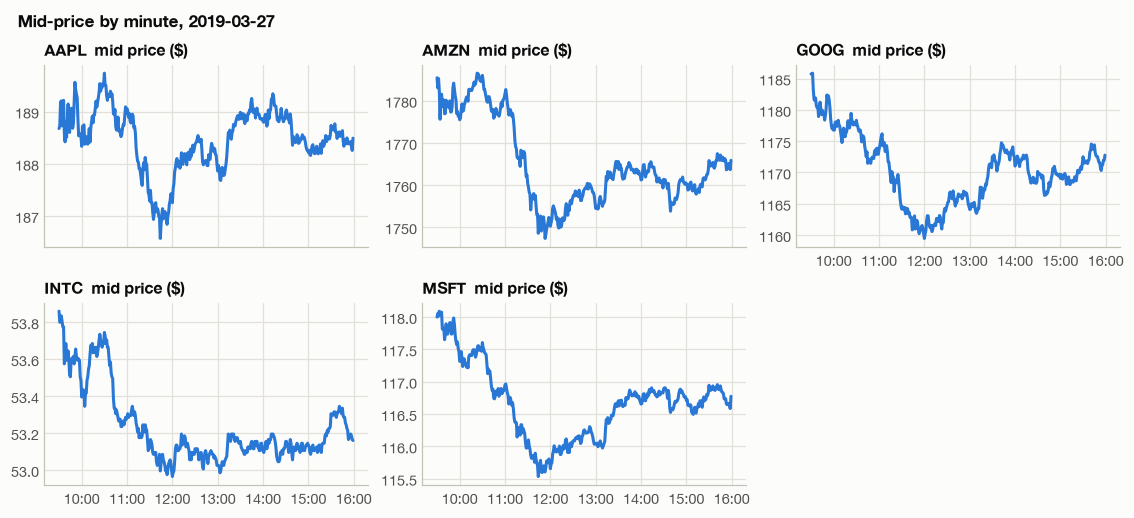

,open,low,high,close
AAPL,188.675,186.570,189.735,188.490
AMZN,1785.450,1747.345,1786.545,1765.865
GOOG,1185.725,1159.465,1185.860,1172.765
INTC,53.860,52.965,53.860,53.160
MSFT,118.000,115.535,118.090,116.775


In [4]:
fig, axes = small_multiples(len(cfg["symbols"]), ncols=3, sharex=True)
table = {}
for ax, s in zip(axes, cfg["symbols"]):
    e = events[s]
    mid = e.loc[e["valid"]].set_index("ts")["mid"].resample("1min").last().dropna()
    table[s] = pd.Series({"open": mid.iloc[0], "low": mid.min(), "high": mid.max(), "close": mid.iloc[-1]})
    ax.plot(mid.index, mid.to_numpy(), color=SERIES[0])
    ax.set_title(f"{s}  mid price ($)")
    ax.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter("%H:%M"))
fig.suptitle(f"Mid-price by minute, {', '.join(sorted(set(DAY.values())))}", x=0.01, ha="left",
             fontweight="semibold")
plt.show()
pd.DataFrame(table).T.round(3)

## 2 · Spread in ticks

Time-weighted: each second of the session counts once (the 1-second grid). Large-tick stocks (about $30) should sit at one tick almost all the time; high-priced stocks spread over several ticks.

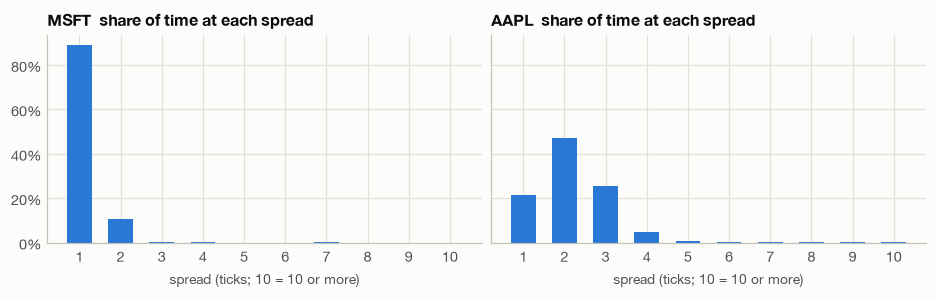

,MSFT,AAPL
spread_ticks,,
1.0,89.1%,21.5%
2.0,10.6%,47.1%
3.0,0.3%,25.7%
4.0,0.0%,4.7%
5.0,0.0%,0.7%
6.0,0.0%,0.2%
7.0,0.0%,0.1%
8.0,0.0%,0.0%
9.0,0.0%,0.0%


In [5]:
pair = [s for s in ("MSFT", "AAPL") if s in cfg["symbols"]] or cfg["symbols"][:2]
fig, axes = small_multiples(len(pair), ncols=2, sharex=True, sharey=True, panel=(4.2, 2.6))
shares = {}
for ax, s in zip(axes, pair):
    ticks = grids[s]["spread_ticks"].dropna().round().clip(upper=10)
    share = ticks.value_counts(normalize=True).sort_index()
    shares[s] = share
    ax.bar(share.index, share.to_numpy(), width=0.6, color=SERIES[0])
    ax.set_title(f"{s}  share of time at each spread")
    ax.set_xlabel("spread (ticks; 10 = 10 or more)")
    ax.set_xticks(range(1, 11))
    ax.yaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(1.0))
plt.show()
pd.DataFrame(shares).fillna(0).map(lambda v: f"{v:.1%}")

## 3 · Level-1 imbalance vs the next 30 s mid move (training window only)

Imbalance = (bid size − ask size) / (bid size + ask size), in deciles. A positive slope means a bid-heavy book tends to be followed by a rising mid: the first sign of whether the signal exists.

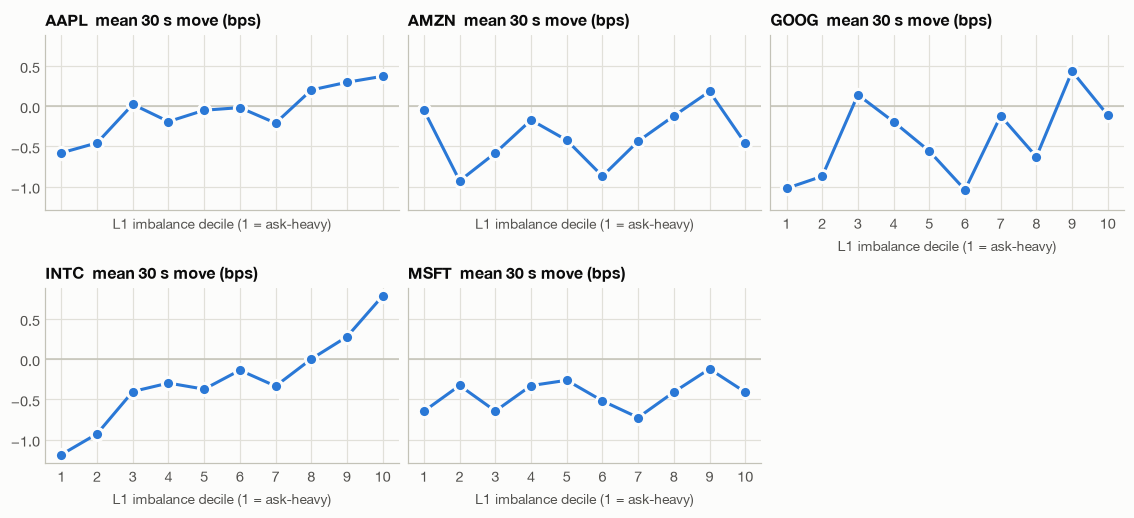

,AAPL,AMZN,GOOG,INTC,MSFT
decile,,,,,
1,-0.580,-0.050,-1.022,-1.186,-0.646
2,-0.455,-0.928,-0.871,-0.927,-0.327
3,0.023,-0.580,0.142,-0.402,-0.645
4,-0.191,-0.172,-0.194,-0.297,-0.328
5,-0.050,-0.423,-0.558,-0.372,-0.262
6,-0.018,-0.869,-1.040,-0.137,-0.518
7,-0.210,-0.436,-0.121,-0.335,-0.725
8,0.201,-0.121,-0.628,0.002,-0.409
9,0.297,0.183,0.434,0.280,-0.121


In [6]:
from adaptive_exec.pipeline import make_units, main_kind

units = [u for u in make_units(cfg) if u.kind == main_kind(cfg)]
first = {}
for u in units:
    first.setdefault(u.test.symbol, u)
fig, axes = small_multiples(len(first), ncols=3, sharex=True, sharey=True)
rows = {}
for ax, (s, u) in zip(axes, first.items()):
    g = pd.concat([grids[s][p.window.mask(grids[s]["ts"])] for p in u.train if p.date == DAY[s]])
    g = g.dropna(subset=["imb_l1", "y_bps_30"])
    dec = pd.qcut(g["imb_l1"].rank(method="first"), 10, labels=False) + 1
    stat = g.groupby(dec)["y_bps_30"].mean()
    rows[s] = stat
    ax.plot(stat.index, stat.to_numpy(), "-o", color=SERIES[0])
    zero_line(ax)
    ax.set_title(f"{s}  mean 30 s move (bps)")
    ax.set_xlabel("L1 imbalance decile (1 = ask-heavy)")
    ax.set_xticks(range(1, 11))
plt.show()
pd.DataFrame(rows).round(3).rename_axis("decile")

## 4 · Trades per minute

Should show the intraday U-shape: busy open and close, quiet midday.

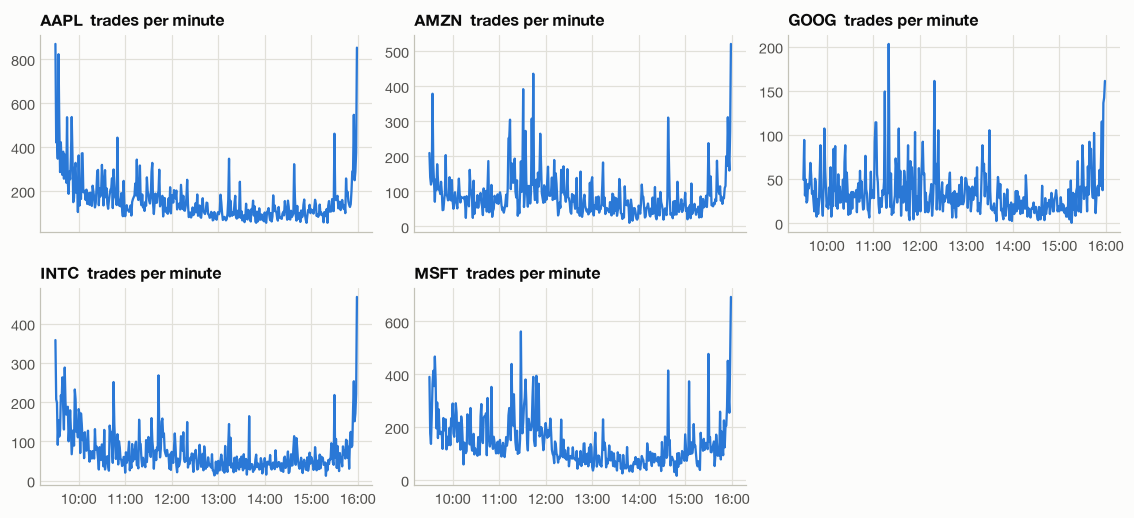

,mean,50%,max
AAPL,157.4,131.0,869.0
AMZN,86.3,73.0,520.0
GOOG,34.5,29.0,203.0
INTC,71.9,55.0,468.0
MSFT,140.1,114.0,693.0


In [7]:
fig, axes = small_multiples(len(cfg["symbols"]), ncols=3, sharex=True)
per_min = {}
for ax, s in zip(axes, cfg["symbols"]):
    e = events[s]
    tpm = e.loc[e["is_trade"]].set_index("ts")["size"].resample("1min").count()
    per_min[s] = tpm.describe()[["mean", "50%", "max"]]
    ax.plot(tpm.index, tpm.to_numpy(), color=SERIES[0], linewidth=1.5)
    ax.set_title(f"{s}  trades per minute")
    ax.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter("%H:%M"))
plt.show()
pd.DataFrame(per_min).T.round(1)

**Questions to answer from these plots (two sentences each):** How often is each stock at a
one-tick spread? Does the imbalance slope look stronger for the large-tick stocks (long queues,
so imbalance carries most of the information) than for the high-priced ones? Where in the day
is activity concentrated, and does the proxy volume curve have the same shape?

## 5 · One parent order, fill by fill (validation window)

The Phase 2 check: a VWAP buy of 5% of expected volume, starting at the beginning of the
validation window, traced decision by decision. Below, one slice's resting-order fills are
recomputed **independently from the raw events** (plain pandas, no simulator code), and the
cost breakdown is checked against the plain IS formula. No model is needed for this.

In [8]:
from adaptive_exec.experiment import settings
from adaptive_exec.pipeline import load_events, reference_daily_volume, symbol_sigma, volume_curve
from adaptive_exec.simulator import (MarketContext, MarketReplay, expected_volume,
                                     make_parent_orders, run_parent_order)
from adaptive_exec.strategies import VWAP

unit = units[0]
period = unit.validate[0]
curve = volume_curve(cfg, unit, period)
v_ref = reference_daily_volume(cfg, unit, period)
market = MarketContext(curve=curve, sigma_daily_bps=symbol_sigma(cfg, unit, period.symbol),
                       daily_volume=v_ref)
o = cfg["orders"]
orders = make_parent_orders(period.window.start, period.window.end,
                            lambda s, h: expected_volume(curve, v_ref, s, h, o["slice_s"]),
                            o["targets"], o["every_min"], o["horizon_min"], o["slice_s"])
order = next(x for x in orders if x.side == 1 and x.size_target == 0.05)
full_events = load_events(cfg, period.symbol, period.date)
replay = MarketReplay(full_events, cfg["levels"])
s_cons = settings(cfg, cfg["tuning"]["impact"], "conservative")
r = run_parent_order(replay, order, VWAP(), market, s_cons, trace=True)
print(f"{period.symbol} {period.date}: buy {order.qty:,} shares from {order.start:%H:%M} for "
      f"{order.horizon_s // 60} min; arrival mid {r['arrival_mid']:.4f}")
decisions = pd.DataFrame(r["decisions"])
decisions.head(12)

AAPL 2019-03-27: buy 14,298 shares from 12:40 for 30 min; arrival mid 188.2800


,slice,t_s,bid,bid_size,ask,ask_size,pred_bps,tactic,speed,scheduled,schedule_cum,catch_up,to_cross,to_post,post_px,queue_ahead,filled_in_slice,n_fills,done_cum
0,0,0.0,188.27,2100.0,188.29,200.0,NaN,baseline,1.0,249,249,0,0,249,188.27,2100.0,249,1,249
1,1,30.0,188.04,100.0,188.07,359.0,NaN,baseline,1.0,249,498,0,0,249,188.04,100.0,249,1,498
2,2,60.0,188.02,614.0,188.05,307.0,NaN,baseline,1.0,249,747,0,0,249,188.02,614.0,0,0,498
3,3,90.0,188.03,346.0,188.06,429.0,NaN,baseline,1.0,249,996,0,0,249,188.03,346.0,249,1,747
4,4,120.0,187.97,451.0,187.99,700.0,NaN,baseline,1.0,249,1245,0,0,249,187.97,451.0,0,0,747
5,5,150.0,188.14,273.0,188.16,500.0,NaN,baseline,1.0,249,1494,0,0,249,188.14,273.0,249,1,996
6,6,180.0,188.01,220.0,188.03,200.0,NaN,baseline,1.0,249,1743,0,0,249,188.01,220.0,249,3,1245
7,7,210.0,188.08,300.0,188.10,200.0,NaN,baseline,1.0,249,1992,0,0,249,188.08,300.0,249,1,1494
8,8,240.0,188.02,800.0,188.04,200.0,NaN,baseline,1.0,249,2241,0,0,249,188.02,800.0,249,1,1743
9,9,270.0,188.10,200.0,188.11,400.0,NaN,baseline,1.0,249,2490,0,0,249,188.10,200.0,249,1,1992


In [9]:
fills = pd.DataFrame([f.__dict__ for f in r["fills"]])
print(f"{len(fills)} fills, {r['filled']:,} shares filled, passive share {r['passive_share']:.1%}, "
      f"unfilled {r['unfilled']}")
fills.head(12)

73 fills, 14,298 shares filled, passive share 83.4%, unfilled 0


,t,px,px_adj,mid,qty,passive,fee
0,8.025751,188.27,188.270000,188.260,249,True,-0.498
1,58.869474,188.04,188.044872,188.035,249,True,-0.498
2,90.488570,188.03,188.039622,188.030,249,True,-0.498
3,152.343727,188.14,188.153098,188.135,249,True,-0.498
4,183.043499,188.01,188.027296,188.015,17,True,-0.034
5,183.043518,188.01,188.027670,188.015,10,True,-0.020
6,183.202414,188.01,188.027884,188.005,222,True,-0.444
7,214.840805,188.08,188.101171,188.075,249,True,-0.498
8,243.190265,188.02,188.044954,188.015,249,True,-0.498
9,271.910767,188.10,188.128491,188.095,249,True,-0.498


In [10]:
# Independent recomputation of the first slice that had resting fills
sl = decisions[(decisions["to_post"] > 0) & (decisions["n_fills"] > 0)]
assert len(sl), "no slice with resting fills in this order; try another start time"
row = sl.iloc[0]
t0 = order.start + pd.Timedelta(seconds=row["t_s"])
t1 = t0 + pd.Timedelta(seconds=order.slice_s)
px, ahead, qty = row["post_px"], row["queue_ahead"], row["to_post"]

trades = full_events[full_events["is_trade"] & (full_events["ts"] > t0) & (full_events["ts"] <= t1)]
hits = trades[(trades["aggressor"] == -1) & (np.round(trades["price"] * 1e4) <= round(px * 1e4))]
mine, left = [], qty
for p, size in zip(hits["price"], hits["size"]):
    if left == 0:
        break
    if round(p * 1e4) < round(px * 1e4):          # traded through our bid: the rest fills
        take = left
    else:                                        # at our price: the queue ahead goes first
        used = min(ahead, size)
        ahead -= used
        take = min(size - used, left)
    if take:
        mine.append(int(take))
        left -= take

sim = fills[(fills["passive"]) & (fills["t"] > row["t_s"]) & (fills["t"] <= row["t_s"] + order.slice_s)]
print(f"slice {int(row['slice'])}: posted {int(qty)} at {px:.4f} behind {int(row['queue_ahead'])} shares")
print("independent fills:", mine)
print("simulator fills:  ", sim["qty"].astype(int).tolist())
assert mine == sim["qty"].astype(int).tolist()

slice 0: posted 249 at 188.2700 behind 2100 shares
independent fills: [249]
simulator fills:   [249]


In [11]:
from adaptive_exec.metrics import implementation_shortfall_bps

parts = ["spread_bps", "drift_bps", "impact_bps", "fees_bps", "opportunity_bps"]
pseudo = [(f.px_adj, f.qty) for f in r["fills"]]
if r["unfilled"]:
    pseudo.append((r["end_mid"] + r["end_half_spread"], r["unfilled"]))
plain = implementation_shortfall_bps(1, r["arrival_mid"], pseudo, sum(f.fee for f in r["fills"]))
print(pd.Series({p: r[p] for p in parts + ["is_bps"]}).round(4).to_string())
print(f"plain IS formula: {plain:.4f} bps")
assert abs(sum(r[p] for p in parts) - r["is_bps"]) < 1e-9 and abs(plain - r["is_bps"]) < 1e-9

spread_bps          0.3328
drift_bps         -15.2383
impact_bps          2.7725
fees_bps           -0.0621
opportunity_bps     0.0000
is_bps            -12.1950
plain IS formula: -12.1950 bps
